# MSA-CNN - Multi-Scale Attention 1D CNN

Custom 1D CNN for intrusion detection using multi-scale convolution branches, channel attention, residual blocks, and pooled classification features.


## Path Configuration

The synthetic ZIP can be provided through Kaggle input paths, `SYN_ZIP_PATH`, `DATA_ROOT`, or a local data directory.


In [ ]:
import json
import random
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
)

import torch
from torch import nn
from torch.utils.data import DataLoader

REPO_ROOT = Path("/kaggle/input/datasets/kashyap1264/src-rawal/Thesis_repo_fixed/").resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.models import MSACNN
from src.losses import FocalLoss
from src.dataset import TabularDataset, make_weighted_loader, make_eval_loader
from src.training import predict, train_model

GLOBAL_SEED = 42

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything(GLOBAL_SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

OUT_ROOT = Path("msa_cnn_artifacts")
for d in [OUT_ROOT / "unsw" / "binary",
          OUT_ROOT / "unsw" / "multiclass",
          OUT_ROOT / "synthetic_transfer" / "binary",
          OUT_ROOT / "synthetic_transfer" / "multiclass",
          OUT_ROOT / "combined"]:
    d.mkdir(parents=True, exist_ok=True)

USE_HF_DOWNLOAD = False
UNSW_TRAIN_CSV = "/kaggle/input/datasets/mrwellsdavid/unsw-nb15/UNSW_NB15_testing-set.csv"
UNSW_TEST_CSV  = "/kaggle/input/datasets/mrwellsdavid/unsw-nb15/UNSW_NB15_training-set.csv"
SYN_ROOT = "/kaggle/input/datasets/synthetic-data/synthetic_ipv6_grounded_v3_32x32"

CNN_SEEDS    = [11, 22, 33, 44, 55]
VAL_SIZE     = 0.15
EPOCHS       = 25
PATIENCE     = 6
LR           = 1e-3
WEIGHT_DECAY = 1e-4
BATCH_SIZE   = 256
FOCAL_GAMMA  = 2.0
BASE_CHANNELS = 64
DROPOUT       = 0.4
UNSTABLE_SUPPORT_THRESHOLD = 5

MODEL_NAME = "msa_cnn"


Device: cuda


## Dataset Loading


In [20]:
if USE_HF_DOWNLOAD:
    from huggingface_hub import hf_hub_download
    HF_REPO = "Mouwiya/UNSW-NB15-small"
    UNSW_TRAIN_CSV = hf_hub_download(repo_id=HF_REPO, filename="UNSW_NB15_training-set.csv", repo_type="dataset")
    UNSW_TEST_CSV  = hf_hub_download(repo_id=HF_REPO, filename="UNSW_NB15_testing-set.csv",  repo_type="dataset")

unsw_train = pd.read_csv(UNSW_TRAIN_CSV)
unsw_test  = pd.read_csv(UNSW_TEST_CSV)
print("UNSW  train:", len(unsw_train), "| test:", len(unsw_test))

syn_flows = pd.read_csv(f"{SYN_ROOT}/flows.csv")
syn_test_ids = pd.read_csv(f"{SYN_ROOT}/test.csv")
syn_test = syn_flows.merge(syn_test_ids[["record_id"]], on="record_id", how="inner")
print("Synthetic test:", len(syn_test))


UNSW  train: 175341 | test: 82332
Synthetic test: 450


## Shared Helpers


In [21]:
def normalize_attack_name(x):
    if pd.isna(x):
        return "Unknown"
    s = str(x).strip()
    return "Benign" if s.lower() == "normal" else s

def save_json(obj, path):
    Path(path).write_text(json.dumps(obj, indent=2))

def save_text(text, path):
    Path(path).write_text(str(text))

def support_flag_table(labels, threshold=5):
    vc = pd.Series(labels).value_counts().sort_values(ascending=True)
    out = vc.rename_axis("label").reset_index(name="support")
    out["unstable"] = out["support"] < threshold
    return out

def prepare_unsw_task(task="multiclass"):
    tr, te = unsw_train.copy(), unsw_test.copy()
    if task == "multiclass":
        target = "attack_cat"
        tr[target] = tr[target].apply(normalize_attack_name)
        te[target] = te[target].apply(normalize_attack_name)
        drop_cols = ["id", "label"]
        labels = sorted(pd.Series(tr[target]).unique().tolist())
    else:
        target = "label"
        tr[target] = tr[target].astype(str).map(lambda x: "Attack" if str(x) == "1" else "Benign")
        te[target] = te[target].astype(str).map(lambda x: "Attack" if str(x) == "1" else "Benign")
        drop_cols = ["id", "attack_cat"]
        labels = ["Benign", "Attack"]
    X_pool = tr.drop(columns=[target] + drop_cols, errors="ignore").reset_index(drop=True)
    y_pool = tr[target].astype(str).values
    X_test = te.drop(columns=[target] + drop_cols, errors="ignore").reset_index(drop=True)
    y_test = te[target].astype(str).values
    return X_pool, y_pool, X_test, y_test, labels

def prepare_synthetic_eval(task="multiclass"):
    te = syn_test.copy()
    if task == "multiclass":
        te["label"] = te["label"].astype(str).apply(lambda s: "Benign" if s.lower() == "normal" else s)
        labels = sorted(pd.Series(te["label"]).unique().tolist())
    else:
        te["label"] = te["label"].astype(str).map(lambda x: "Benign" if x == "Benign" else "Attack")
        labels = ["Benign", "Attack"]
    X_test = te.drop(columns=["label", "record_id", "window_start_utc", "window_end_utc", "src_ip", "dst_ip"], errors="ignore")
    y_test = te["label"].astype(str).values
    return X_test.reset_index(drop=True), y_test, labels

def align_to_reference_columns(X, ref_cols):
    X = X.copy()
    for c in [c for c in ref_cols if c not in X.columns]:
        X[c] = np.nan
    return X[ref_cols], [c for c in ref_cols if c not in X.columns]

def fit_tabular_vectorizer(X_train):
    cat_cols = [c for c in X_train.columns if X_train[c].dtype == "object"]
    num_cols = [c for c in X_train.columns if c not in cat_cols]
    vec = ColumnTransformer([
        ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                          ("sc", StandardScaler(with_mean=True))]), num_cols),
        ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                          ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]), cat_cols),
    ], remainder="drop")
    vec.fit(X_train)
    vec.ref_cols_ = list(X_train.columns)
    return vec

def transform_with_tabular_vectorizer(vec, X):
    X_aligned, _ = align_to_reference_columns(X, vec.ref_cols_)
    return vec.transform(X_aligned).astype(np.float32)

def multiclass_metrics(y_true, y_pred, labels):
    acc = accuracy_score(y_true, y_pred)
    pm, rm, f1m, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", labels=labels, zero_division=0)
    _, _, f1w, _   = precision_recall_fscore_support(y_true, y_pred, average="weighted", labels=labels, zero_division=0)
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    report = classification_report(y_true, y_pred, labels=labels, zero_division=0, digits=4)
    return {"accuracy": float(acc), "macro_precision": float(pm), "macro_recall": float(rm),
            "macro_f1": float(f1m), "weighted_f1": float(f1w), "confusion_matrix": cm.tolist(), "report": report}

def binary_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="binary", pos_label="Attack", zero_division=0)
    cm = confusion_matrix(y_true, y_pred, labels=["Benign", "Attack"])
    report = classification_report(y_true, y_pred, labels=["Benign", "Attack"], digits=4, zero_division=0)
    return {"accuracy": float(acc), "precision": float(p), "recall": float(r),
            "f1": float(f1), "confusion_matrix": cm.tolist(), "report": report}

def choose_binary_threshold(probs, y_val_lbl, label_order):
    attack_idx = label_order.index("Attack")
    scores = probs[:, attack_idx]
    y01 = (pd.Series(y_val_lbl) == "Attack").astype(int).values
    prec, rec, thr = precision_recall_curve(y01, scores)
    f1 = (2 * prec * rec) / np.clip(prec + rec, 1e-8, None)
    if len(thr) == 0:
        return 0.5
    return float(thr[int(np.nanargmax(f1[:-1]))])

def make_model_dirs(root_base, task, model_name):
    d = root_base / task / model_name
    for sub in ["figures", "tables", "metrics", "reports", "models"]:
        (d / sub).mkdir(parents=True, exist_ok=True)
    return d

def plot_confusion(cm, labels, title, save_path, max_labels=20):
    show_labels = labels[:max_labels]
    show_cm = np.array(cm)[:max_labels, :max_labels]
    plt.figure(figsize=(8, 6))
    plt.imshow(show_cm)
    plt.title(title)
    plt.xlabel("Predicted"); plt.ylabel("True"); plt.colorbar()
    ticks = np.arange(len(show_labels))
    plt.xticks(ticks, show_labels, rotation=45, ha="right")
    plt.yticks(ticks, show_labels)
    plt.tight_layout()
    plt.savefig(save_path, dpi=180, bbox_inches="tight")
    plt.show()

def plot_training_curves(history, prefix, save_dir):
    epochs = list(range(1, len(history["train_loss"]) + 1))
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(epochs, history["train_loss"]); ax1.set(title="Train loss", xlabel="Epoch", ylabel="Loss")
    ax2.plot(epochs, history["val_acc"], label="val_acc")
    ax2.plot(epochs, history["val_macro_f1"], label="val_macro_f1")
    ax2.set(title="Validation metrics", xlabel="Epoch", ylabel="Score"); ax2.legend()
    plt.tight_layout()
    plt.savefig(save_dir / f"{prefix}_curves.png", dpi=180, bbox_inches="tight")
    plt.show()


## Evaluation Runner

UNSW-NB15 training with validation early stopping, UNSW test evaluation, and synthetic IPv6 transfer evaluation across saved seeds.


In [22]:
def run_msa_cnn(task):
    
    X_pool, y_pool, X_unsw_test, y_unsw_test, label_order = prepare_unsw_task(task)
    X_syn_test, y_syn_test, _ = prepare_synthetic_eval(task)

    unsw_dir = make_model_dirs(OUT_ROOT / "unsw", task, MODEL_NAME)
    syn_dir  = make_model_dirs(OUT_ROOT / "synthetic_transfer", task, MODEL_NAME)

    support_flag_table(y_unsw_test, UNSTABLE_SUPPORT_THRESHOLD).to_csv(
        unsw_dir / "tables" / "test_support_flags.csv", index=False)
    support_flag_table(y_syn_test, UNSTABLE_SUPPORT_THRESHOLD).to_csv(
        syn_dir / "tables" / "test_support_flags.csv", index=False)

    unsw_runs, syn_runs = [], []

    for seed in CNN_SEEDS:
        seed_everything(seed)
        print(f"\n{'='*60}\n  {MODEL_NAME} | {task} | seed={seed}\n{'='*60}")

        X_tr, X_val, y_tr_lbl, y_val_lbl = train_test_split(
            X_pool, y_pool, test_size=VAL_SIZE, random_state=seed, stratify=y_pool)

        label2id = {l: i for i, l in enumerate(label_order)}
        id2label = {i: l for l, i in label2id.items()}

        keep = pd.Series(y_syn_test).isin(label_order).values
        X_syn_eval = X_syn_test.loc[keep].reset_index(drop=True)
        y_syn_eval_lbl = pd.Series(y_syn_test)[keep].reset_index(drop=True).values

        y_tr   = pd.Series(y_tr_lbl).map(label2id).astype(int).values
        y_val  = pd.Series(y_val_lbl).map(label2id).astype(int).values
        y_ut   = pd.Series(y_unsw_test).map(label2id).astype(int).values
        y_st   = pd.Series(y_syn_eval_lbl).map(label2id).astype(int).values

        vec  = fit_tabular_vectorizer(X_tr)
        Xtr  = transform_with_tabular_vectorizer(vec, X_tr)
        Xval = transform_with_tabular_vectorizer(vec, X_val)
        Xu   = transform_with_tabular_vectorizer(vec, X_unsw_test)
        Xs   = transform_with_tabular_vectorizer(vec, X_syn_eval)

        train_loader, class_weights = make_weighted_loader(Xtr, y_tr, BATCH_SIZE)
        val_loader  = make_eval_loader(Xval, y_val)
        unsw_loader = make_eval_loader(Xu, y_ut)
        syn_loader  = make_eval_loader(Xs, y_st)

        n_cls = len(label_order)
        model = MSACNN(n_classes=n_cls, base_channels=BASE_CHANNELS, dropout=DROPOUT).to(DEVICE)
        alpha = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)
        criterion = FocalLoss(alpha=alpha, gamma=FOCAL_GAMMA)
        optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

        save_path = unsw_dir / "models" / f"{MODEL_NAME}_seed_{seed}.pt"
        history, best_state = train_model(
            model, train_loader, val_loader, criterion, optimizer,
            DEVICE, n_cls, epochs=EPOCHS, patience=PATIENCE,
            save_path=save_path, prefix=f"seed_{seed}")

        model.load_state_dict(best_state)
        model.to(DEVICE)

        yv_true, yv_pred, yv_probs = predict(model, val_loader, DEVICE)
        yt_true, yt_pred, yt_probs = predict(model, unsw_loader, DEVICE)
        ys_true, ys_pred, ys_probs = predict(model, syn_loader, DEVICE)

        if task == "binary":
            threshold = choose_binary_threshold(yv_probs, y_val_lbl, label_order)
            aidx = label_order.index("Attack")
            yt_pred_lbl = np.where(yt_probs[:, aidx] >= threshold, "Attack", "Benign")
            ys_pred_lbl = np.where(ys_probs[:, aidx] >= threshold, "Attack", "Benign")
        else:
            threshold = None
            yt_pred_lbl = pd.Series(yt_pred).map(id2label).values
            ys_pred_lbl = pd.Series(ys_pred).map(id2label).values

        if task == "binary":
            mu = binary_metrics(y_unsw_test, yt_pred_lbl)
            ms = binary_metrics(y_syn_eval_lbl, ys_pred_lbl)
            unsw_runs.append({"seed": seed, "threshold": threshold,
                              "accuracy": mu["accuracy"], "precision": mu["precision"],
                              "recall": mu["recall"], "f1": mu["f1"]})
            syn_runs.append({"seed": seed, "threshold": threshold,
                             "accuracy": ms["accuracy"], "precision": ms["precision"],
                             "recall": ms["recall"], "f1": ms["f1"],
                             "rows_kept": len(y_syn_eval_lbl), "rows_total": len(y_syn_test)})
        else:
            mu = multiclass_metrics(y_unsw_test, yt_pred_lbl, label_order)
            ms = multiclass_metrics(y_syn_eval_lbl, ys_pred_lbl, label_order)
            unsw_runs.append({"seed": seed, "accuracy": mu["accuracy"],
                              "macro_precision": mu["macro_precision"], "macro_recall": mu["macro_recall"],
                              "macro_f1": mu["macro_f1"], "weighted_f1": mu["weighted_f1"]})
            syn_runs.append({"seed": seed, "accuracy": ms["accuracy"],
                             "macro_precision": ms["macro_precision"], "macro_recall": ms["macro_recall"],
                             "macro_f1": ms["macro_f1"], "weighted_f1": ms["weighted_f1"],
                             "rows_kept": len(y_syn_eval_lbl), "rows_total": len(y_syn_test)})

        if seed == CNN_SEEDS[0]:
            save_text(mu["report"], unsw_dir / "reports" / f"classification_report_seed_{seed}.txt")
            save_text(ms["report"], syn_dir / "reports" / f"classification_report_seed_{seed}.txt")
            plot_training_curves(history, f"{MODEL_NAME}_seed_{seed}", unsw_dir / "figures")
            if task == "binary":
                plot_confusion(mu["confusion_matrix"], ["Benign","Attack"],
                               f"{MODEL_NAME} UNSW binary", unsw_dir / "figures" / f"confusion_seed_{seed}.png")
                plot_confusion(ms["confusion_matrix"], ["Benign","Attack"],
                               f"{MODEL_NAME} Synthetic binary", syn_dir / "figures" / f"confusion_seed_{seed}.png")
            else:
                plot_confusion(mu["confusion_matrix"], label_order,
                               f"{MODEL_NAME} UNSW multiclass", unsw_dir / "figures" / f"confusion_seed_{seed}.png")
                plot_confusion(ms["confusion_matrix"], label_order,
                               f"{MODEL_NAME} Synthetic multiclass", syn_dir / "figures" / f"confusion_seed_{seed}.png")

    unsw_df = pd.DataFrame(unsw_runs)
    syn_df  = pd.DataFrame(syn_runs)
    unsw_df.to_csv(unsw_dir / "tables" / "all_runs.csv", index=False)
    syn_df.to_csv(syn_dir / "tables" / "all_runs.csv", index=False)

    if task == "binary":
        agg_cols = {"accuracy": ["mean","std"], "precision": ["mean","std"],
                    "recall": ["mean","std"], "f1": ["mean","std"]}
    else:
        agg_cols = {"accuracy": ["mean","std"], "macro_f1": ["mean","std"],
                    "macro_recall": ["mean","std"], "weighted_f1": ["mean","std"]}

    unsw_summary = unsw_df.agg(agg_cols)
    syn_summary  = syn_df.agg(agg_cols)

    save_json(unsw_summary.to_dict(), unsw_dir / "tables" / "summary.json")
    save_json(syn_summary.to_dict(),  syn_dir / "tables" / "summary.json")

    print(f"\n--- {task} UNSW summary ---")
    display(unsw_df)
    print(f"\n--- {task} Synthetic transfer summary ---")
    display(syn_df)

    return unsw_df, syn_df


## Experiment Runs



  msa_cnn | binary | seed=11
  seed_11 | epoch 01 | loss=0.0000 | val_acc=0.9347 | val_macro_f1=0.9244
  seed_11 | epoch 02 | loss=0.0000 | val_acc=0.8944 | val_macro_f1=0.8859
  seed_11 | epoch 03 | loss=0.0000 | val_acc=0.9307 | val_macro_f1=0.9218
  seed_11 | epoch 04 | loss=0.0000 | val_acc=0.7744 | val_macro_f1=0.7701
  seed_11 | epoch 05 | loss=0.0000 | val_acc=0.9344 | val_macro_f1=0.9257
  seed_11 | epoch 06 | loss=0.0000 | val_acc=0.9373 | val_macro_f1=0.9285
  seed_11 | epoch 07 | loss=0.0000 | val_acc=0.8565 | val_macro_f1=0.8491
  seed_11 | epoch 08 | loss=0.0000 | val_acc=0.8320 | val_macro_f1=0.8253
  seed_11 | epoch 09 | loss=0.0000 | val_acc=0.9295 | val_macro_f1=0.9214
  seed_11 | epoch 10 | loss=0.0000 | val_acc=0.9229 | val_macro_f1=0.9144
  seed_11 | epoch 11 | loss=0.0000 | val_acc=0.8815 | val_macro_f1=0.8736
  seed_11 | epoch 12 | loss=0.0000 | val_acc=0.9420 | val_macro_f1=0.9325
  seed_11 | epoch 13 | loss=0.0000 | val_acc=0.8955 | val_macro_f1=0.8873
  seed_1

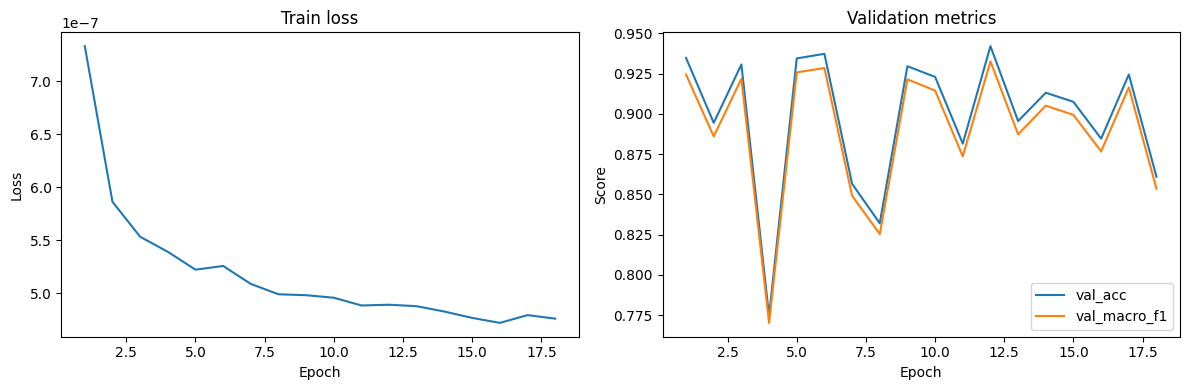

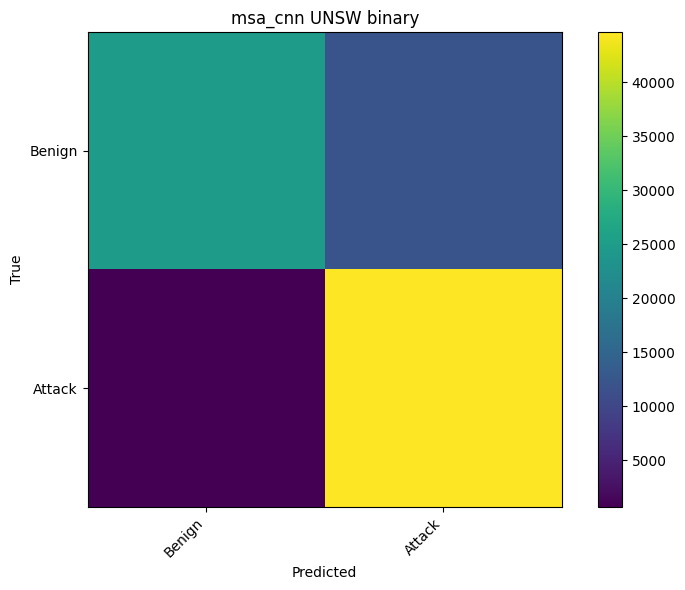

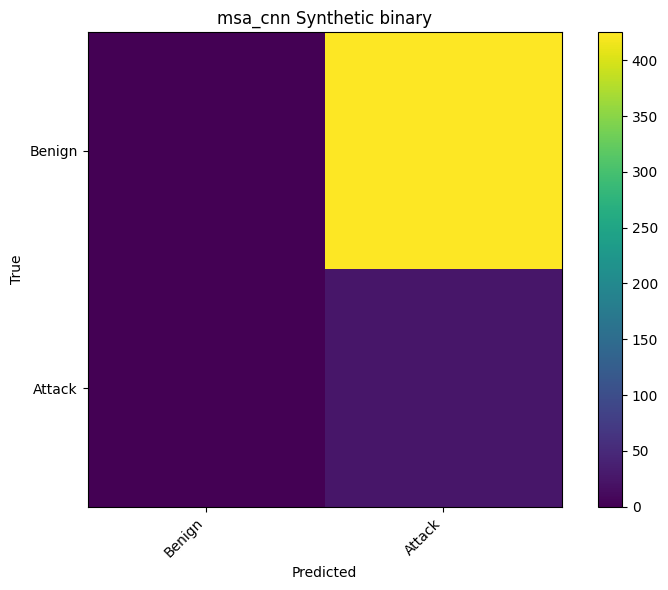


  msa_cnn | binary | seed=22
  seed_22 | epoch 01 | loss=0.0000 | val_acc=0.8107 | val_macro_f1=0.8047
  seed_22 | epoch 02 | loss=0.0000 | val_acc=0.8891 | val_macro_f1=0.8806
  seed_22 | epoch 03 | loss=0.0000 | val_acc=0.9089 | val_macro_f1=0.9006
  seed_22 | epoch 04 | loss=0.0000 | val_acc=0.8761 | val_macro_f1=0.8680
  seed_22 | epoch 05 | loss=0.0000 | val_acc=0.7891 | val_macro_f1=0.7842
  seed_22 | epoch 06 | loss=0.0000 | val_acc=0.9132 | val_macro_f1=0.9050
  seed_22 | epoch 07 | loss=0.0000 | val_acc=0.9429 | val_macro_f1=0.9333
  seed_22 | epoch 08 | loss=0.0000 | val_acc=0.9376 | val_macro_f1=0.9279
  seed_22 | epoch 09 | loss=0.0000 | val_acc=0.9011 | val_macro_f1=0.8927
  seed_22 | epoch 10 | loss=0.0000 | val_acc=0.9109 | val_macro_f1=0.9028
  seed_22 | epoch 11 | loss=0.0000 | val_acc=0.7448 | val_macro_f1=0.7419
  seed_22 | epoch 12 | loss=0.0000 | val_acc=0.9123 | val_macro_f1=0.9042
  seed_22 | epoch 13 | loss=0.0000 | val_acc=0.9351 | val_macro_f1=0.9270
  Early 

,seed,threshold,accuracy,precision,recall,f1
0,11,0.478098,0.845030,0.787245,0.984647,0.874950
1,22,0.500680,0.857322,0.802203,0.983323,0.883577
2,33,0.518419,0.865775,0.814984,0.978316,0.889212
3,44,0.457089,0.860139,0.805081,0.984294,0.885713
4,55,0.454442,0.839637,0.781601,0.983588,0.871038



--- binary Synthetic transfer summary ---


,seed,threshold,accuracy,precision,recall,f1,rows_kept,rows_total
0,11,0.478098,0.055556,0.055556,1.0,0.105263,450,450
1,22,0.500680,0.055556,0.055556,1.0,0.105263,450,450
2,33,0.518419,0.055556,0.055556,1.0,0.105263,450,450
3,44,0.457089,0.055556,0.055556,1.0,0.105263,450,450
4,55,0.454442,0.055556,0.055556,1.0,0.105263,450,450



  msa_cnn | multiclass | seed=11
  seed_11 | epoch 01 | loss=0.0003 | val_acc=0.2175 | val_macro_f1=0.1191
  seed_11 | epoch 02 | loss=0.0002 | val_acc=0.3720 | val_macro_f1=0.2098
  seed_11 | epoch 03 | loss=0.0001 | val_acc=0.5720 | val_macro_f1=0.3058
  seed_11 | epoch 04 | loss=0.0001 | val_acc=0.5620 | val_macro_f1=0.3032
  seed_11 | epoch 05 | loss=0.0001 | val_acc=0.5692 | val_macro_f1=0.3037
  seed_11 | epoch 06 | loss=0.0001 | val_acc=0.6311 | val_macro_f1=0.3384
  seed_11 | epoch 07 | loss=0.0001 | val_acc=0.5964 | val_macro_f1=0.3214
  seed_11 | epoch 08 | loss=0.0001 | val_acc=0.6113 | val_macro_f1=0.3608
  seed_11 | epoch 09 | loss=0.0001 | val_acc=0.6274 | val_macro_f1=0.3594
  seed_11 | epoch 10 | loss=0.0001 | val_acc=0.6453 | val_macro_f1=0.4043
  seed_11 | epoch 11 | loss=0.0001 | val_acc=0.6166 | val_macro_f1=0.3641
  seed_11 | epoch 12 | loss=0.0001 | val_acc=0.6510 | val_macro_f1=0.4008
  seed_11 | epoch 13 | loss=0.0001 | val_acc=0.6330 | val_macro_f1=0.3667
  se

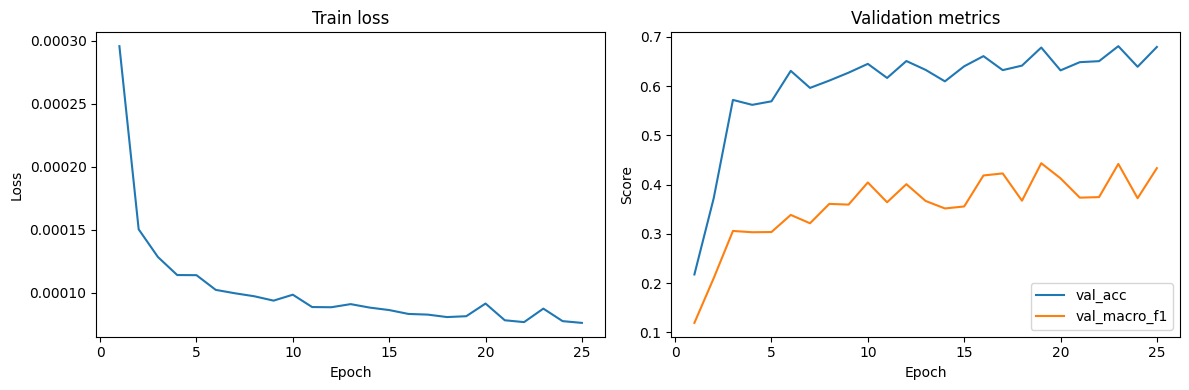

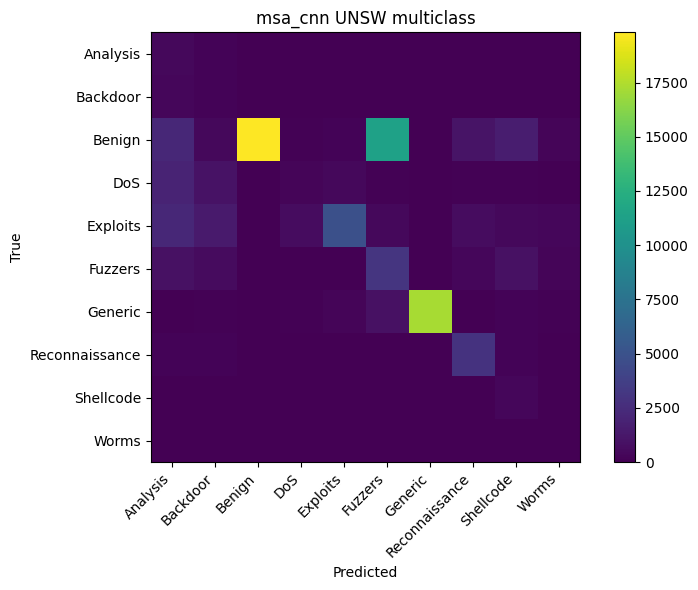

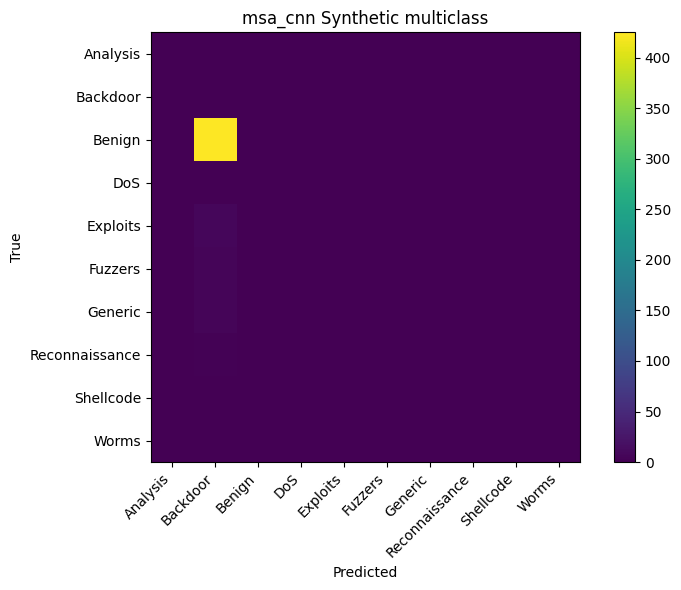


  msa_cnn | multiclass | seed=22
  seed_22 | epoch 01 | loss=0.0003 | val_acc=0.2220 | val_macro_f1=0.1123
  seed_22 | epoch 02 | loss=0.0001 | val_acc=0.5280 | val_macro_f1=0.2675
  seed_22 | epoch 03 | loss=0.0001 | val_acc=0.5670 | val_macro_f1=0.3072
  seed_22 | epoch 04 | loss=0.0001 | val_acc=0.5912 | val_macro_f1=0.3303
  seed_22 | epoch 05 | loss=0.0001 | val_acc=0.6054 | val_macro_f1=0.3477
  seed_22 | epoch 06 | loss=0.0001 | val_acc=0.6146 | val_macro_f1=0.3601
  seed_22 | epoch 07 | loss=0.0001 | val_acc=0.6299 | val_macro_f1=0.3308
  seed_22 | epoch 08 | loss=0.0001 | val_acc=0.5980 | val_macro_f1=0.3008
  seed_22 | epoch 09 | loss=0.0001 | val_acc=0.6063 | val_macro_f1=0.3404
  seed_22 | epoch 10 | loss=0.0001 | val_acc=0.6355 | val_macro_f1=0.3648
  seed_22 | epoch 11 | loss=0.0001 | val_acc=0.6549 | val_macro_f1=0.4040
  seed_22 | epoch 12 | loss=0.0001 | val_acc=0.6183 | val_macro_f1=0.3410
  seed_22 | epoch 13 | loss=0.0001 | val_acc=0.6106 | val_macro_f1=0.3292
  se

,seed,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
0,11,0.595309,0.400432,0.576710,0.364252,0.664279
1,22,0.601127,0.397742,0.554500,0.352912,0.666170
2,33,0.520114,0.446766,0.456095,0.355368,0.616932
3,44,0.576398,0.395855,0.526579,0.356356,0.649811
4,55,0.494449,0.404697,0.488517,0.321429,0.592714



--- multiclass Synthetic transfer summary ---


,seed,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,rows_kept,rows_total
0,11,0.0,0.0,0.0,0.0,0.0,450,450
1,22,0.0,0.0,0.0,0.0,0.0,450,450
2,33,0.0,0.0,0.0,0.0,0.0,450,450
3,44,0.0,0.0,0.0,0.0,0.0,450,450
4,55,0.0,0.0,0.0,0.0,0.0,450,450


In [23]:
results = {}
for task in ["binary", "multiclass"]:
    unsw_df, syn_df = run_msa_cnn(task)
    results[task] = {"unsw": unsw_df, "synthetic": syn_df}


## Comparison Tables


In [24]:
drop_rows = []
for task in ["binary", "multiclass"]:
    u = results[task]["unsw"]
    s = results[task]["synthetic"]
    if task == "binary":
        drop_rows.append({
            "task": task, "model": MODEL_NAME,
            "unsw_accuracy_mean": u["accuracy"].mean(),
            "synthetic_accuracy_mean": s["accuracy"].mean(),
            "accuracy_drop": u["accuracy"].mean() - s["accuracy"].mean(),
            "unsw_f1_mean": u["f1"].mean(),
            "synthetic_f1_mean": s["f1"].mean(),
            "f1_drop": u["f1"].mean() - s["f1"].mean(),
        })
    else:
        drop_rows.append({
            "task": task, "model": MODEL_NAME,
            "unsw_accuracy_mean": u["accuracy"].mean(),
            "synthetic_accuracy_mean": s["accuracy"].mean(),
            "accuracy_drop": u["accuracy"].mean() - s["accuracy"].mean(),
            "unsw_macro_f1_mean": u["macro_f1"].mean(),
            "synthetic_macro_f1_mean": s["macro_f1"].mean(),
            "macro_f1_drop": u["macro_f1"].mean() - s["macro_f1"].mean(),
        })

drop_df = pd.DataFrame(drop_rows)
drop_df.to_csv(OUT_ROOT / "combined" / "msa_cnn_drop_analysis.csv", index=False)

print("Drop analysis — MSA-CNN")
display(drop_df)

dummy = MSACNN(n_classes=10, base_channels=BASE_CHANNELS, dropout=DROPOUT)
n_params = sum(p.numel() for p in dummy.parameters())
print(f"\nMSA-CNN total parameters: {n_params:,}")


Drop analysis — MSA-CNN


,task,model,unsw_accuracy_mean,synthetic_accuracy_mean,accuracy_drop,unsw_f1_mean,synthetic_f1_mean,f1_drop,unsw_macro_f1_mean,synthetic_macro_f1_mean,macro_f1_drop
0,binary,msa_cnn,0.853581,0.055556,0.798025,0.880898,0.105263,0.775635,NaN,NaN,NaN
1,multiclass,msa_cnn,0.557479,0.000000,0.557479,NaN,NaN,NaN,0.350063,0.0,0.350063



MSA-CNN total parameters: 161,050


## Artifact Dashboard


In [25]:
def list_files(folder):
    return sorted([p.name for p in folder.glob("*")]) if folder.exists() else []

dashboard = {}
for root_name, root_path in {"unsw": OUT_ROOT / "unsw",
                              "synthetic_transfer": OUT_ROOT / "synthetic_transfer"}.items():
    dashboard[root_name] = {}
    for task in ["binary", "multiclass"]:
        model_dir = root_path / task / MODEL_NAME
        dashboard[root_name][task] = {
            sub: list_files(model_dir / sub)
            for sub in ["tables", "figures", "metrics", "reports", "models"]
        }

dashboard["combined"] = list_files(OUT_ROOT / "combined")
save_json(dashboard, OUT_ROOT / "combined" / "artefact_dashboard.json")
dashboard


{'unsw': {'binary': {'tables': ['all_runs.csv',
    'summary.json',
    'test_support_flags.csv'],
   'figures': ['confusion_seed_11.png', 'msa_cnn_seed_11_curves.png'],
   'metrics': [],
   'reports': ['classification_report_seed_11.txt'],
   'models': ['msa_cnn_seed_11.pt',
    'msa_cnn_seed_22.pt',
    'msa_cnn_seed_33.pt',
    'msa_cnn_seed_44.pt',
    'msa_cnn_seed_55.pt']},
  'multiclass': {'tables': ['all_runs.csv',
    'summary.json',
    'test_support_flags.csv'],
   'figures': ['confusion_seed_11.png', 'msa_cnn_seed_11_curves.png'],
   'metrics': [],
   'reports': ['classification_report_seed_11.txt'],
   'models': ['msa_cnn_seed_11.pt',
    'msa_cnn_seed_22.pt',
    'msa_cnn_seed_33.pt',
    'msa_cnn_seed_44.pt',
    'msa_cnn_seed_55.pt']}},
 'synthetic_transfer': {'binary': {'tables': ['all_runs.csv',
    'summary.json',
    'test_support_flags.csv'],
   'figures': ['confusion_seed_11.png'],
   'metrics': [],
   'reports': ['classification_report_seed_11.txt'],
   'models':